In [1]:
#open file

import pandas as pd 
import numpy as np

from glob import glob

files = glob("./output/*_out.csv")

data = pd.DataFrame()

for file in files:
    frame = pd.read_csv(file, header=None)
    data = pd.concat([data, frame])

print(data.shape)


#sort into columns

model = data.iloc[:,0]
grade = data.iloc[:,1]
text = data.iloc[:,2]
prompt = data.iloc[:,3]
start_grade = data.iloc[:,4]
target_grade = data.iloc[:,5]
output_grade = data.iloc[:,6]

data.columns = ["model", "grade", "text", "prompt", "start_grade", "target_grade", "output_grade"]





/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


(5145, 7)


In [2]:
distance_start_to_target = target_grade - start_grade

data["distance_start_to_target"] = distance_start_to_target

In [3]:
distance_target_to_output = abs(output_grade - target_grade)

data["distance_target_to_output"] = distance_target_to_output

#qwen text 0 grade 10 prompt 6 is largest with distance 85,000 so presumably an outlier. Should check on prompts output.

data = data[data["distance_target_to_output"] < 1000]

In [4]:
data["text_and_grade_identifier"] = data["grade"].astype(str) + data["text"].astype(str)

In [5]:
data["direction"] = (data["target_grade"] - data["grade"] >= 0).astype(int)

In [112]:
print(data[0:20])

         model  grade  text  prompt  start_grade  target_grade  output_grade  \
0   gemma4:e4b      0     0       0         0.44             0          0.52   
1   gemma4:e4b      0     0       1         0.44             0          0.18   
2   gemma4:e4b      0     0       2         0.44             0         -0.42   
3   gemma4:e4b      0     0       3         0.44             0         11.93   
4   gemma4:e4b      0     0       4         0.44             0          8.97   
5   gemma4:e4b      0     0       5         0.44             0          0.19   
6   gemma4:e4b      0     0       6         0.44             0         -0.29   
7   gemma4:e4b      0     0       0         0.44             2          1.01   
8   gemma4:e4b      0     0       1         0.44             2         -0.00   
9   gemma4:e4b      0     0       2         0.44             2          0.23   
10  gemma4:e4b      0     0       3         0.44             2         11.34   
11  gemma4:e4b      0     0       4     

In [113]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * distance_start_to_target * C(model)",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())


/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


                                   Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             distance_target_to_output
No. Observations:             5144                Method:                         REML                     
No. Groups:                   21                  Scale:                          5.3897                   
Min. group size:              244                 Log-Likelihood:                 -11733.9837              
Max. group size:              245                 Converged:                      Yes                      
Mean group size:              245.0                                                                        
-----------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------

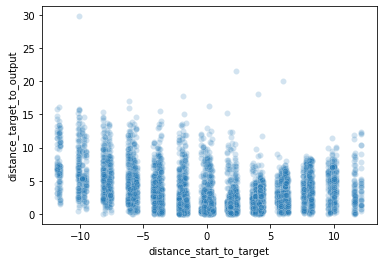

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=data,
    x="distance_start_to_target",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

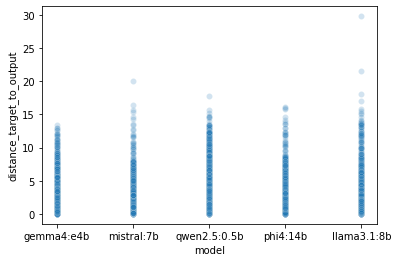

In [115]:
sns.scatterplot(
    data=data,
    x="model",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

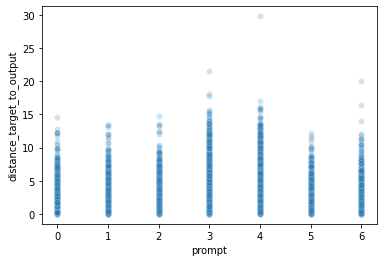

In [116]:
sns.scatterplot(
    data=data,
    x="prompt",
    y="distance_target_to_output",
    alpha=0.2
)

plt.show()

In [117]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * distance_start_to_target * C(model)",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


                                   Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             distance_target_to_output
No. Observations:             5144                Method:                         REML                     
No. Groups:                   21                  Scale:                          5.3897                   
Min. group size:              244                 Log-Likelihood:                 -11733.9837              
Max. group size:              245                 Converged:                      Yes                      
Mean group size:              245.0                                                                        
-----------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------

In [ ]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * C(model) + distance_start_to_target",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

In [ ]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) + C(model) * distance_start_to_target",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

                            Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        distance_target_to_output
No. Observations:         5144           Method:                    REML                     
No. Groups:               21             Scale:                     5.3738                   
Min. group size:          244            Log-Likelihood:            -11687.2103              
Max. group size:          245            Converged:                 Yes                      
Mean group size:          245.0                                                              
---------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                          0.356    0.235   1.510 0.131 -0.106  

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [ ]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) + distance_start_to_target * C(model) ",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

                            Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        distance_target_to_output
No. Observations:         5144           Method:                    REML                     
No. Groups:               21             Scale:                     5.3738                   
Min. group size:          244            Log-Likelihood:            -11687.2103              
Max. group size:          245            Converged:                 Yes                      
Mean group size:          245.0                                                              
---------------------------------------------------------------------------------------------
                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                          0.356    0.235   1.510 0.131 -0.106  

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [6]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) + distance_start_to_target + C(model) + direction",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: distance_target_to_output
No. Observations: 5144    Method:             REML                     
No. Groups:       21      Scale:              6.7786                   
Min. group size:  244     Log-Likelihood:     -12262.7277              
Max. group size:  245     Converged:          Yes                      
Mean group size:  245.0                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.071    0.197 15.549 0.000  2.684  3.458
C(prompt)[T.1]               -0.106    0.136 -0.780 0.435 -0.372  0.160
C(prompt)[T.2]               -0.021    0.136 -0.156 0.876 -0.287  0.245
C(prompt)[T.3]                1.929    0.136 14.201 0.000  1.662  2.195
C(prompt)

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [7]:
mixed_effects_model = smf.mixedlm("distance_target_to_output ~ C(prompt) * C(model) + distance_start_to_target",
    data,
    groups=data["text_and_grade_identifier"])
result = mixed_effects_model.fit()

print(result.summary())

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

                       Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     distance_target_to_output
No. Observations:     5144        Method:                 REML                     
No. Groups:           21          Scale:                  6.3161                   
Min. group size:      244         Log-Likelihood:         -12075.4178              
Max. group size:      245         Converged:              No                       
Mean group size:      245.0                                                        
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                2.000    0.246   8.139 0.000  1.518  2.481
C(prompt)[T.1]                           0.067    0.293   0.227 0.820 -0.508  0.641
C(prompt)[T.2] 

<AxesSubplot:xlabel='prompt', ylabel='model'>

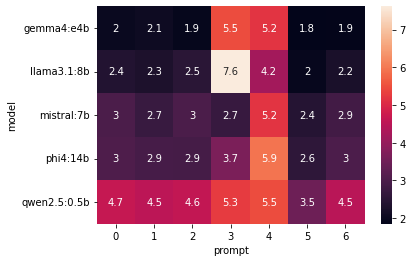

In [15]:
import seaborn as sns

pivot = data.pivot_table(values="distance_target_to_output", index="model", columns="prompt", aggfunc="mean")

sns.heatmap(pivot, annot=True)

<AxesSubplot:xlabel='distance_start_to_target', ylabel='model'>

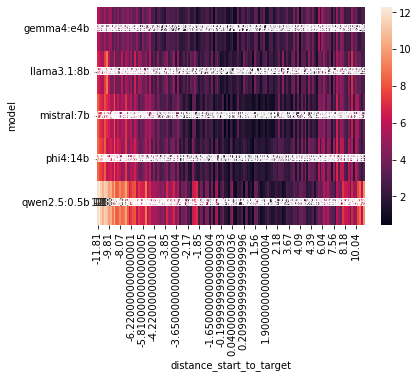

In [9]:
import seaborn as sns

pivot = data.pivot_table(

values="distance_target_to_output",

index="model",

columns="distance_start_to_target",

aggfunc="mean"
)

sns.heatmap(pivot, annot=True)